In [ ]:
# !pip install yfinance

In [49]:
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Download Netflix data
df = yf.download("NFLX", start="2015-01-01", end="2025-01-01")

df = df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()

# Force flatten the table (The "Scorched Earth" Fix)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1) # Kill the 'NFLX' header row

df = df.reset_index() # Move 'Date' from the side to a real column
print(df.tail())

# Use only the last 365 days so candles are thick and visible for plotting
df_plot = df.tail(365)

# A candlestick is a visual representation of price action over a specific period. Without the full set of data, the geometry of the candle cannot be drawn:
figure = go.Figure(data=[go.Candlestick(
    x=df_plot['Date'],
    open=df_plot['Open'],
    high=df_plot['High'],
    low=df_plot['Low'],
    close=df_plot['Close']
)])

figure.update_layout(
    title="Netflix Stock Price (Daily Candlesticks)",
    xaxis_rangeslider_visible=False,
    template="plotly_white"
)

figure.show()

/tmp/ipykernel_9335/667593691.py:8: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

Price       Date       Open       High        Low      Close    Volume
2511  2024-12-24  91.500000  93.584999  91.169998  93.211998  23203000
2512  2024-12-26  92.839996  93.049004  91.529999  92.414001  23403000
2513  2024-12-27  91.600998  91.813004  89.449997  90.754997  32262000
2514  2024-12-30  89.450996  90.822998  88.971001  90.042999  22030000
2515  2024-12-31  90.180000  90.267998  88.946999  89.132004  18759000


### Normalize data (important for CNN)

In [32]:
# # Approach 1: scaling
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# df_norm = scaler.fit_transform(df)

# Approach 2: standardization
# Drop the 'Date' column before standardization as it's not a numerical feature for the model
df_numeric = df.drop(columns=['Date'])
df_norm = (df_numeric - df_numeric.mean()) / df_numeric.std()

print(df_norm.head())

Price      Open      High       Low     Close    Volume
0     -1.511167 -1.513591 -1.504323 -1.507578  0.570036
1     -1.510602 -1.519182 -1.512770 -1.520946  1.154949
2     -1.520676 -1.527616 -1.520691 -1.525213  0.889643
3     -1.520676 -1.528755 -1.517439 -1.523941  0.117907
4     -1.521873 -1.526596 -1.516334 -1.518477  0.087003


In [43]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

data = df_norm[['Close', 'Volume']].values

# Create sequences (Window size = 60 timesteps e.g., days)
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length, 0] # Predict next 'Close'
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

window_size = 60
X, y = create_sequences(data, window_size)

# PyTorch expects shape: [Batch, Channels, Seq_Length]
# Currently we have: [Batch, Seq_Length, Channels] -> We must transpose
X = torch.from_numpy(X).float().transpose(1, 2)
y = torch.from_numpy(y).float().unsqueeze(1)

# Split and Load
train_size = int(len(X) * 0.8)

# 2. Slice the tensors (No shuffling here!)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=32,
    shuffle=True
)

print(f"Shape of X_train: {X_train.shape}") # n_batch, n_feature, n_timesteps
print(f"Shape of y_train: {y_train.shape}") # n_feature = 1 because we want to predict 'Close' price
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {X_test.shape}")

Shape of X_train: torch.Size([1964, 2, 60])
Shape of y_train: torch.Size([1964, 1])
Shape of X_test: torch.Size([492, 2, 60])
Shape of y_test: torch.Size([492, 2, 60])


In [40]:
# Build the CNN Model
model = nn.Sequential(
    # First Conv layer: Extracts patterns from the 60-day window
    nn.Conv1d(in_channels=2, out_channels=64, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),

    # Second Conv layer: Deepens the feature extraction
    nn.Conv1d(in_channels=64, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),

    nn.Flatten(),
    nn.Linear(in_features=32 * 13, out_features=50), # Calculated input features: 32 channels * 13 sequence length
    nn.ReLU(),
    nn.Dropout(0.2), # Prevents overfitting
    nn.Linear(in_features=50, out_features=1)      # Final output: Predicted Close Price
)

# In PyTorch, model.compile is not used.
print(model)


Sequential(
  (0): Conv1d(2, 64, kernel_size=(3,), stride=(1,))
  (1): ReLU()
  (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv1d(64, 32, kernel_size=(3,), stride=(1,))
  (4): ReLU()
  (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=416, out_features=50, bias=True)
  (8): ReLU()
  (9): Dropout(p=0.2, inplace=False)
  (10): Linear(in_features=50, out_features=1, bias=True)
)


In [41]:
# The optimizer and loss function are defined separately before training.
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [53]:
epochs = 50

train_losses = []
test_losses = []

model.train() # Set model to training mode

for epoch in range(epochs):
    total_train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()       # Clear old gradients
        outputs = model(batch_X)     # Forward pass
        loss = criterion(outputs, batch_y)
        loss.backward()             # Backward pass (gradients)
        optimizer.step()            # Update weights
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluate on the test set after each epoch
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        test_outputs = model(X_test)
        current_test_loss = criterion(test_outputs, y_test).item()
    test_losses.append(current_test_loss)
    model.train() # Set back to training mode for next epoch

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Training Loss: {avg_train_loss:.6f}, Test Loss: {current_test_loss:.6f}")

Epoch [10/50], Training Loss: 0.016020, Test Loss: 0.056775
Epoch [20/50], Training Loss: 0.015280, Test Loss: 0.042019
Epoch [30/50], Training Loss: 0.015320, Test Loss: 0.050306
Epoch [40/50], Training Loss: 0.014775, Test Loss: 0.094751
Epoch [50/50], Training Loss: 0.013135, Test Loss: 0.057149


Test MSE: 0.057149


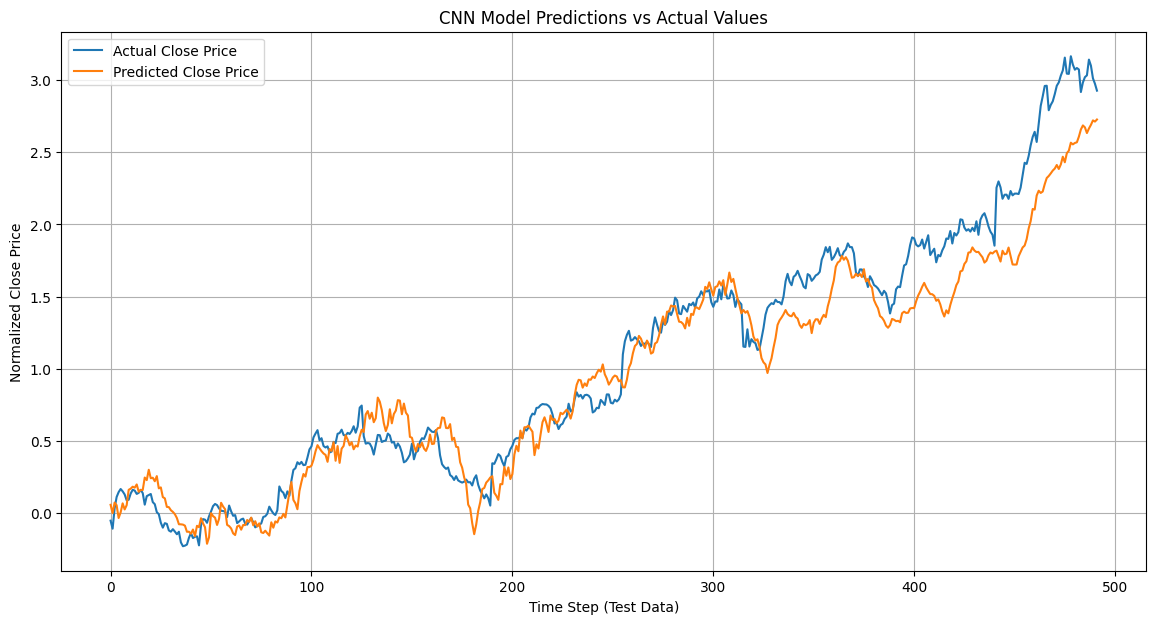

In [54]:
import matplotlib.pyplot as plt

model.eval() # Set model to evaluation mode (turns off Dropout)

with torch.no_grad():
    predictions = model(X_test)
    test_loss = criterion(predictions, y_test) # Calculate Test Loss (MSE)

    # Convert to numpy for plotting/analysis
    y_test_np = y_test.numpy()
    predictions_np = predictions.numpy()
print(f"Test MSE: {test_loss.item():.6f}")

# --- Plotting losses ---
# plt.figure(figsize=(10, 6))
# plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
# plt.plot(range(1, epochs + 1), test_losses, label='Test Loss')
# plt.title('Training and Test Loss Over Epochs')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()
# plt.grid(True)
# plt.show()

# --- Plotting prediction aginst actual test values ---
plt.figure(figsize=(14, 7))
plt.plot(y_test_np, label='Actual Close Price')
plt.plot(predictions_np, label='Predicted Close Price')
plt.title('CNN Model Predictions vs Actual Values')
plt.xlabel('Time Step (Test Data)')
plt.ylabel('Normalized Close Price')
plt.legend()
plt.grid(True)
plt.show()

### Multi-Step Future Predictions

Try multi-step predictions for the next 1, 3, 6, and 12 months.
- Each new prediction will be incorporated into the input sequence for the next prediction.
- Use the actual `Volume` from the test set for constructing subsequent input sequences to provide a fair comparison against the test data.

<u>**Note**</u>  
- 1 month: Approximately 21 trading days (5 days/week * 4.2 weeks/month).
- 3 months: Approximately 63 trading days (21 days/month * 3 months).
- 6 months: Approximately 126 trading days (21 days/month * 6 months).
- 12 months: Approximately 252 trading days (21 days/month * 12 months).

In [55]:
# Define prediction horizons in trading days
horizons = {
    "1 month": 21,
    "3 months": 63,
    "6 months": 126,
    "12 months": 252
}
max_horizon_days = horizons["12 months"]

# Ensure model is in evaluation mode
model.eval()

# Start multi-step prediction from the end of the training data
# The 'data' variable contains df_norm[['Close', 'Volume']].values
# 'train_size' is the split point for the data.
# The initial sequence for prediction is the last 'window_size' data points from the training part of 'data'.
initial_sequence_for_prediction = data[train_size - window_size : train_size] # Shape: (window_size, 2)

predicted_future_closes = []
current_sequence_np = initial_sequence_for_prediction.copy()

with torch.no_grad():
    for i in range(max_horizon_days):
        # Convert the current numpy sequence to a PyTorch tensor
        # Expected shape for model input: (Batch_size, Channels, Sequence_length) = (1, 2, 60)
        input_tensor = torch.from_numpy(current_sequence_np).float().transpose(0, 1).unsqueeze(0)

        # Get the model's prediction for the next Close price
        predicted_close_normalized = model(input_tensor).item()
        predicted_future_closes.append(predicted_close_normalized)

        # Prepare the next input sequence:
        # The 'Close' value will be our predicted value.
        # For 'Volume', we'll use the actual volume from the dataset for the corresponding day
        # in the test set, as we are comparing against y_test.
        if (train_size + window_size + i) < len(data):
            next_volume_normalized = data[train_size + window_size + i, 1]
        else:
            # Fallback if predicting beyond the original `data` (should not be reached for max_horizon_days=252 given len(y_test)=492)
            next_volume_normalized = current_sequence_np[-1, 1] # Use the last known volume

        # Create a new data point using the predicted Close and the next Volume
        new_data_point_np = np.array([predicted_close_normalized, next_volume_normalized])

        # Update current_sequence_np: remove the oldest entry, add the new entry
        current_sequence_np = np.vstack((current_sequence_np[1:], new_data_point_np))

predicted_future_closes_np = np.array(predicted_future_closes).reshape(-1, 1)

print(f"Generated {len(predicted_future_closes_np)} multi-step predictions.")

Generated 252 multi-step predictions.


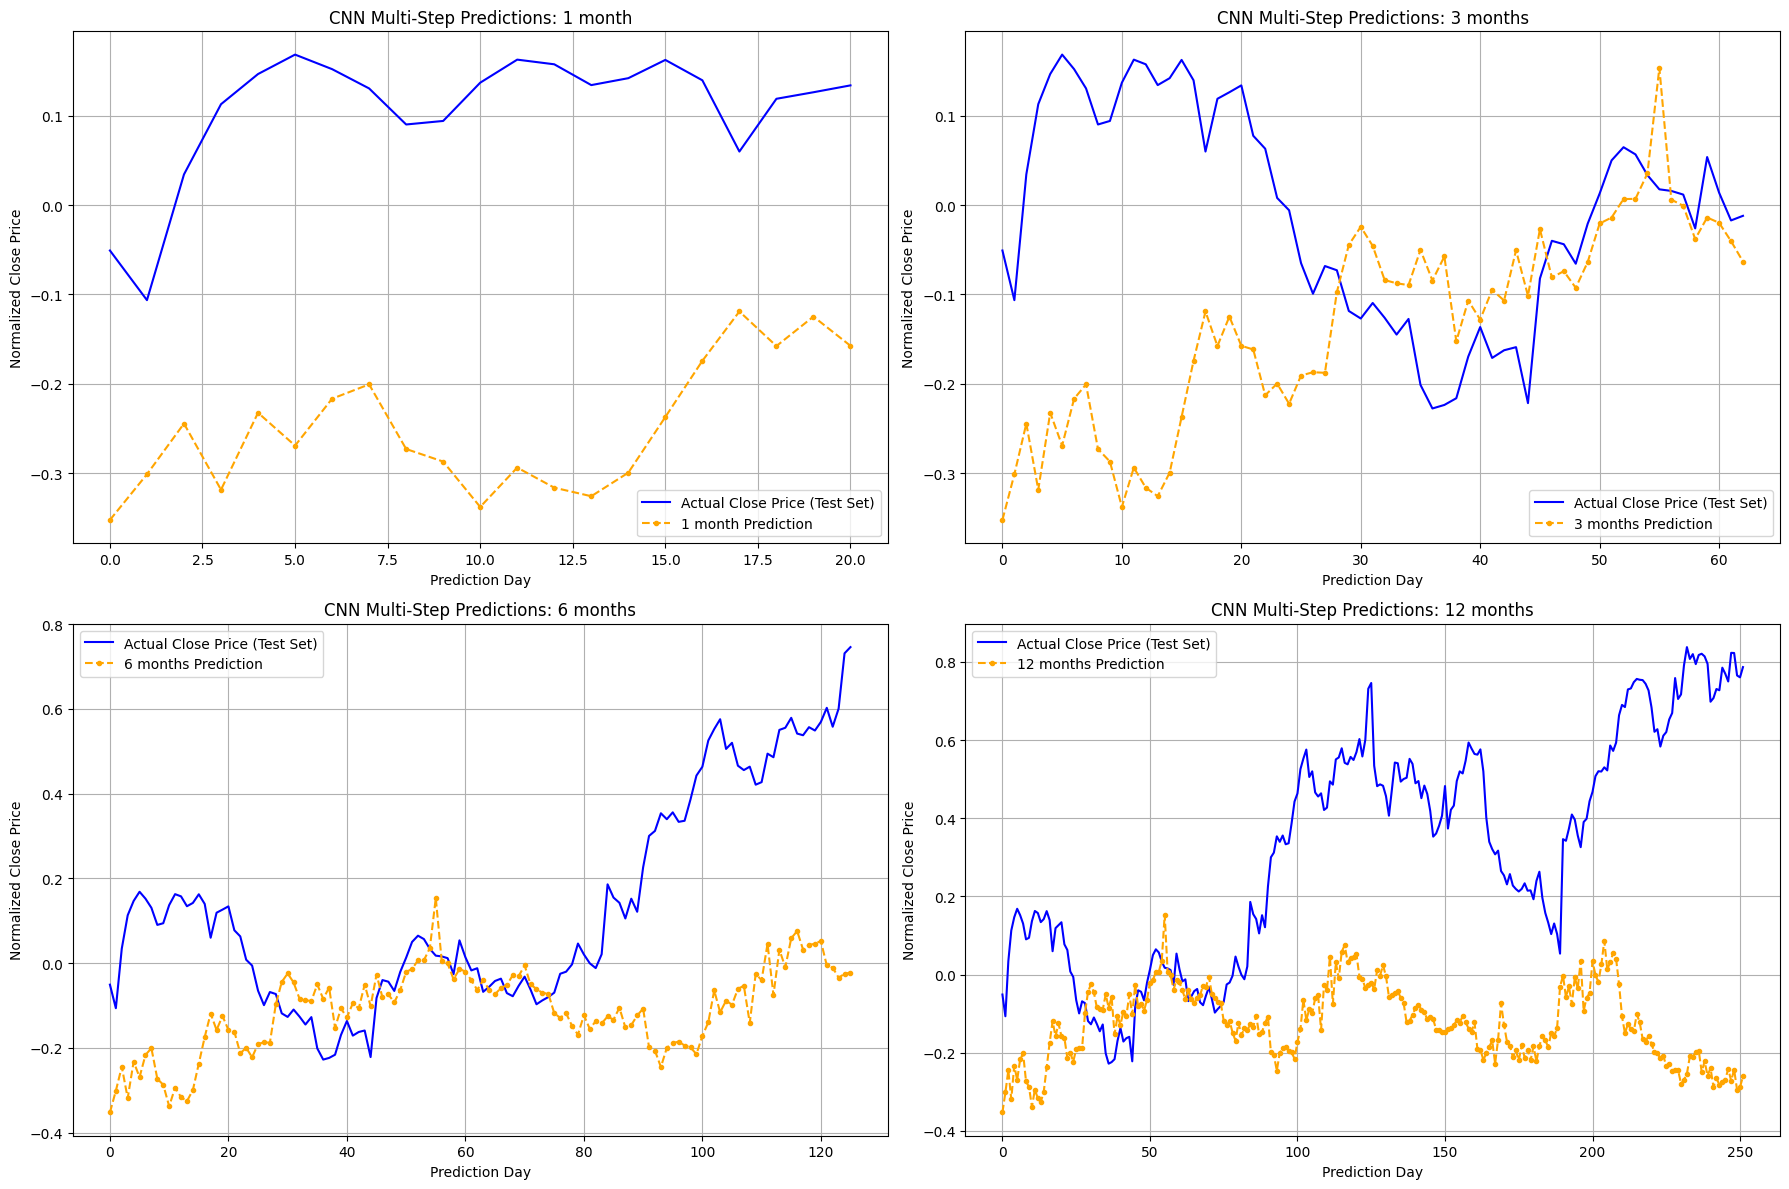

In [56]:
model.eval() # Set model to evaluation mode (turns off Dropout)

# --- Plotting multi-step predictions against actual test values ---

fig, axes = plt.subplots(2, 2, figsize=(18, 12)) # Create a 2x2 grid of subplots
axes = axes.flatten() # Flatten the 2x2 array of axes for easier iteration

plot_idx = 0
for horizon_name, days in horizons.items():
    ax = axes[plot_idx]

    # Plot actual values up to the current horizon
    ax.plot(y_test_np[:days], label='Actual Close Price (Test Set)', color='blue')

    # Plot predicted values up to the current horizon
    ax.plot(predicted_future_closes_np[:days], label=f'{horizon_name} Prediction', linestyle='--', marker='o', markersize=3, color='orange')

    ax.set_title(f'CNN Multi-Step Predictions: {horizon_name}')
    ax.set_xlabel('Prediction Day')
    ax.set_ylabel('Normalized Close Price')
    ax.legend()
    ax.grid(True)

    plot_idx += 1

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()